Cascading Bandits

BLB(32, 8, p=0.2, delta=0.15)  |  n=100  |  2 runs
  n-step regret = 24.8 ± 0.4 ...Step 1/100 ...
  n-step regret = 24.8 ± 2.4...Step 1/100 ...
  n-step regret = 23.3 ± 1.4c) ...Step 1/100 ...
  n-step regret = 20.1 ± 0.4) ...Step 1/100 ...

Plot saved to cascading_bandits_plot_32_8_0.2_0.15_latest.png


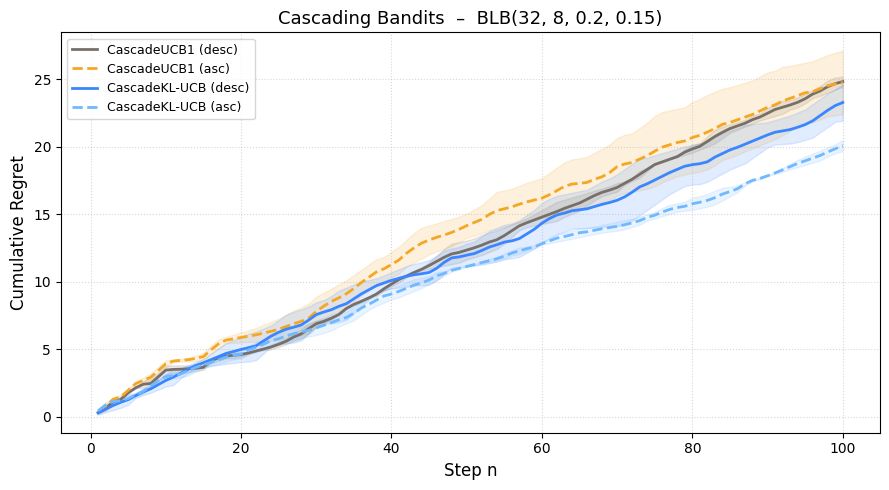

In [15]:
'''Disclaimer: Some portions of this code were generated using AI assistance. All such content has been thoroughly reviewed and refined to ensure correctness and suitability.'''


'''This code was used to generate the table given in report'''

import numpy as np
from scipy.optimize import brentq

def kl_divergence(p: float, q: float, eps: float = 1e-12) -> float:
    """KL divergence between two Bernoulli distributions Bern(p) || Bern(q)."""
    p = np.clip(p, eps, 1 - eps)
    q = np.clip(q, eps, 1 - eps)
    return p * np.log(p / q) + (1 - p) * np.log((1 - p) / (1 - q))


def kl_ucb_upper_bound(p_hat: float, n_obs: int, t: int, eps: float = 1e-9) -> float:
    """
    Compute KL-UCB upper confidence bound.

    Finds the largest q in [p_hat, 1] such that
        n_obs * KL(p_hat || q) <= log(t) + 3 * log(log(t))
    using binary search (Brent's method).
    """
    if n_obs == 0:
        return 1.0
    threshold = np.log(t) + 3.0 * np.log(max(np.log(t), 1.0))
    if n_obs * kl_divergence(p_hat, 1.0 - eps) <= threshold:
        return 1.0 - eps

    def f(q):
        return n_obs * kl_divergence(p_hat, q) - threshold

    lo = p_hat + eps
    hi = 1.0 - eps
    if f(lo) >= 0:
        return lo
    try:
        return brentq(f, lo, hi, xtol=1e-8)
    except ValueError:
        return hi


def simulate_cascade(w_bar: np.ndarray, at: np.ndarray) -> tuple:
    """
    Simulate one step of the cascade model.

    Parameters

    w_bar : attraction probabilities for all L items
    at    : ordered list of K item indices (0-based)

    Returns

    click : position (0-based) of first click, or K if no click
    obs   : binary array of length K; obs[k]=1 iff item at[k] was observed
    """
    K = len(at)
    obs = np.zeros(K, dtype=int)
    for k, item in enumerate(at):
        obs[k] = 1
        if np.random.rand() < w_bar[item]:
            return k, obs          # click at position k
    return K, obs                  # no click


def optimal_reward(w_bar: np.ndarray, K: int) -> float:
    """Expected reward of the optimal list (K most attractive items)."""
    top_k = np.sort(w_bar)[::-1][:K]
    return 1.0 - np.prod(1.0 - top_k)





class CascadeUCB1:
    """
    UCB1-based algorithm for cascading bandits
    Parameters

    L          : total number of items
    K          : list length
    ascending  : if True, recommend items in increasing UCB order
                 if False (default), recommend in decreasing UCB order
    """

    def __init__(self, L: int, K: int, ascending: bool = False):
        self.L = L
        self.K = K
        self.ascending = ascending
        self.name = f"CascadeUCB1 ({'asc' if ascending else 'desc'})"

        # Observation counts and empirical means
        self.T = np.ones(L, dtype=int)
        self.w_hat = np.zeros(L)

    def _ucb(self, t: int) -> np.ndarray:
        """UCB1 confidence radii: sqrt(1.5 * log(t) / T(e))."""
        radius = np.sqrt(1.5 * np.log(max(1, t - 1)) / self.T)
        return np.clip(self.w_hat + radius, 0.0, 1.0)

    def recommend(self, t: int) -> np.ndarray:
        """Return an ordered list of K item indices."""
        ucb = self._ucb(t)
        top_k_idx = np.argpartition(ucb, -self.K)[-self.K:]
        # Sort the chosen K items by UCB (ascending)
        top_k_sorted = top_k_idx[np.argsort(ucb[top_k_idx])]
        if not self.ascending:
            top_k_sorted = top_k_sorted[::-1]   # descending
        return top_k_sorted.copy()

    def update(self, at: np.ndarray, click: int):
        """
        Update statistics after observing a click.
        Parameters
        at    : recommended list (item indices, ordered)
        click : position of click (0-based), or K if no click
        """
        n_obs = min(click + 1, self.K)
        for k in range(n_obs):
            item = at[k]
            old_T = self.T[item]
            self.T[item] += 1
            reward = 1 if k == click else 0
            self.w_hat[item] = (old_T * self.w_hat[item] + reward) / self.T[item]

    def run(self, w_bar: np.ndarray, n: int) -> np.ndarray:
        """
        Run the algorithm for n steps.
        Returns
        cumulative_regret : array of length n
        """
        assert len(w_bar) == self.L
        opt_r = optimal_reward(w_bar, self.K)
        regrets = np.zeros(n)

        # Initialisation: one sample per item (Algorithm 1 in paper)
        for e in range(self.L):
            self.w_hat[e] = float(np.random.rand() < w_bar[e])

        for t in range(1, n + 1):
            print(f"Step {t}/{n} ...", end="\r", flush=True)
            at = self.recommend(t)
            click, _ = simulate_cascade(w_bar, at)
            self.update(at, click)

            list_reward = 1.0 - np.prod(1.0 - w_bar[at])
            regrets[t - 1] = opt_r - list_reward

        return np.cumsum(regrets)




class CascadeKL_UCB:
    """
    KL-UCB-based algorithm for cascading bandits

    Parameters
    L          : total number of items
    K          : list length
    ascending  : ordering of the recommended list

    """

    def __init__(self, L: int, K: int, ascending: bool = False):
        self.L = L
        self.K = K
        self.ascending = ascending
        self.name = f"CascadeKL-UCB ({'asc' if ascending else 'desc'})"

        self.T = np.ones(L, dtype=int)
        self.w_hat = np.zeros(L)

    def _ucb(self, t: int) -> np.ndarray:
        """KL-UCB upper confidence bounds for all items."""
        return np.array([
            kl_ucb_upper_bound(self.w_hat[e], self.T[e], t)
            for e in range(self.L)
        ])

    def recommend(self, t: int) -> np.ndarray:
        ucb = self._ucb(t)
        top_k_idx = np.argpartition(ucb, -self.K)[-self.K:]
        top_k_sorted = top_k_idx[np.argsort(ucb[top_k_idx])]
        if not self.ascending:
            top_k_sorted = top_k_sorted[::-1]
        return top_k_sorted.copy()

    def update(self, at: np.ndarray, click: int):
        n_obs = min(click + 1, self.K)
        for k in range(n_obs):
            item = at[k]
            old_T = self.T[item]
            self.T[item] += 1
            reward = 1 if k == click else 0
            self.w_hat[item] = (old_T * self.w_hat[item] + reward) / self.T[item]

    def run(self, w_bar: np.ndarray, n: int) -> np.ndarray:
        assert len(w_bar) == self.L
        opt_r = optimal_reward(w_bar, self.K)
        regrets = np.zeros(n)

        for e in range(self.L):
            self.w_hat[e] = float(np.random.rand() < w_bar[e])

        for t in range(1, n + 1):
            print(f"Step {t}/{n} ...", end="\r", flush=True)
            at = self.recommend(t)
            click, _ = simulate_cascade(w_bar, at)
            self.update(at, click)

            list_reward = 1.0 - np.prod(1.0 - w_bar[at])
            regrets[t - 1] = opt_r - list_reward

        return np.cumsum(regrets)




class RankedKL_UCB:

    def __init__(self, L: int, K: int):
        self.L = L
        self.K = K
        self.name = "RankedKL-UCB"

        # Separate counts/means per position (K x L)
        self.T = np.ones((K, L), dtype=int)
        self.w_hat = np.zeros((K, L))

    def _ucb(self, t: int) -> np.ndarray:
        """Shape (K, L): KL-UCB for each position-item pair."""
        ucb = np.zeros((self.K, self.L))
        for k in range(self.K):
            for e in range(self.L):
                ucb[k, e] = kl_ucb_upper_bound(self.w_hat[k, e], self.T[k, e], t)
        return ucb

    def recommend(self, t: int) -> np.ndarray:
        ucb = self._ucb(t)
        at = []
        chosen = set()
        for k in range(self.K):
            mask = np.array([e not in chosen for e in range(self.L)])
            candidates = np.where(mask)[0]
            best = candidates[np.argmax(ucb[k, candidates])]
            at.append(int(best))
            chosen.add(int(best))
        return np.array(at)

    def update(self, at: np.ndarray, click: int):
        """
        Update each position's bandit using cascade feedback.
        Position k receives reward 1 only at the click position.
        Items after the click are unobserved.
        """
        for k in range(self.K):
            item = at[k]
            old_T = self.T[k, item]
            self.T[k, item] += 1
            reward = 1 if k == click else 0
            self.w_hat[k, item] = (old_T * self.w_hat[k, item] + reward) / self.T[k, item]
            if k == click:
                break  # items after click are unobserved in the cascade model

    def run(self, w_bar: np.ndarray, n: int) -> np.ndarray:
        assert len(w_bar) == self.L
        opt_r = optimal_reward(w_bar, self.K)
        regrets = np.zeros(n)

        for k in range(self.K):
            for e in range(self.L):
                self.w_hat[k, e] = float(np.random.rand() < w_bar[e])

        for t in range(1, n + 1):
            print(f"Step {t}/{n} ...", end="\r", flush=True)
            at = self.recommend(t)
            click, _ = simulate_cascade(w_bar, at)
            self.update(at, click)

            list_reward = 1.0 - np.prod(1.0 - w_bar[at])
            regrets[t - 1] = opt_r - list_reward

        return np.cumsum(regrets)



def make_blb_problem(L: int, K: int, p: float, delta: float) -> np.ndarray:

    w_bar = np.full(L, p - delta)
    w_bar[:K] = p
    return w_bar


def run_experiment(
    L: int = 32,
    K: int = 8,
    p: float = 0.2,
    delta: float = 0.15,
    n: int = 100_000,
    n_runs: int = 20,
    seed: int = 42,
) -> dict:

    np.random.seed(seed)
    w_bar = make_blb_problem(L, K, p, delta)

    print(f"\nBLB({L}, {K}, p={p}, delta={delta})  |  n={n}  |  {n_runs} runs")

    algorithm_factories = [
        ("CascadeUCB1 (desc)",   lambda: CascadeUCB1(L, K, ascending=False)),
        ("CascadeUCB1 (asc)",    lambda: CascadeUCB1(L, K, ascending=True)),
        ("CascadeKL-UCB (desc)", lambda: CascadeKL_UCB(L, K, ascending=False)),
        ("CascadeKL-UCB (asc)",  lambda: CascadeKL_UCB(L, K, ascending=True))

    ]

    results = {}
    for name, make_alg in algorithm_factories:
        print(f"  Running {name} ...", end="", flush=True)
        runs = np.zeros((n_runs, n))
        for r in range(n_runs):
            alg = make_alg()
            runs[r] = alg.run(w_bar.copy(), n)
        results[name] = runs
        # mean = runs[:, -1].mean()
        # std  = runs[:, -1].std()
        # print(f"  n-step regret = {mean:.1f} ± {std:.1f}")
        mean = runs[:, -1].mean()
        std  = runs[:, -1].std(ddof=1)              # sample std
        sem  = std / np.sqrt(n_runs)                # standard error of mean
        print(f"  n-step regret = {mean:.1f} ± {sem:.1f}")   #  matches paper format

    return results




if __name__ == "__main__":
    print("Cascading Bandits")
    L = 32
    K = 8
    p=0.2
    delta=0.15
    n=100
    n_runs=2
    results = run_experiment(L, K, p, delta, n, n_runs)


    try:
        import matplotlib.pyplot as plt

        steps = np.arange(1, n + 1)
        fig, ax = plt.subplots(figsize=(9, 5))

        colors = {
            "CascadeUCB1 (desc)":   "#776f69",
            "CascadeUCB1 (asc)":    "#f5a623",
            "CascadeKL-UCB (desc)": "#3a86ff",
            "CascadeKL-UCB (asc)":  "#70b8ff"

        }
        styles = {
            "CascadeUCB1 (desc)":   "-",
            "CascadeUCB1 (asc)":    "--",
            "CascadeKL-UCB (desc)": "-",
            "CascadeKL-UCB (asc)":  "--"

        }

        for name, data in results.items():
            mean = data.mean(axis=0)
            std  = data.std(axis=0)
            ax.plot(steps, mean, label=name,
                    color=colors[name], linestyle=styles[name], linewidth=2)
            ax.fill_between(steps, mean - std, mean + std,
                            color=colors[name], alpha=0.15)

        ax.set_xlabel("Step n", fontsize=12)
        ax.set_ylabel("Cumulative Regret", fontsize=12)
        ax.set_title("Cascading Bandits  –  BLB(32, 8, 0.2, 0.15)", fontsize=13)
        ax.legend(loc="upper left", fontsize=9)
        ax.grid(True, linestyle=":", alpha=0.5)
        fig.tight_layout()
        fig.savefig("cascading_bandits_plot_32_8_0.2_0.15_latest.png", dpi=150)
        print("\nPlot saved to cascading_bandits_plot_32_8_0.2_0.15_latest.png")
        plt.show()
    except ImportError:
        print("\n(Install matplotlib to generate a plot.)")

Cascading Bandits – DBN Model Experiment 
L=16, K=4, p=0.2, Δ=0.15, n=100, runs=2

DBN config: γ=1.0, ν=1.0  |  L=16, K=4, p=0.2, Δ=0.15

  Final n-step regret (100 steps, avg over 2 runs):
    CascadeUCB1 (desc)          : 23.5
    CascadeUCB1 (asc)           : 20.5
    CascadeKL-UCB (desc)        : 19.5
    CascadeKL-UCB (asc)         : 20.5
    RankedKL-UCB                : 22.5

DBN config: γ=1.0, ν=0.7  |  L=16, K=4, p=0.2, Δ=0.15

  Final n-step regret (100 steps, avg over 2 runs):
    CascadeUCB1 (desc)          : 17.3
    CascadeUCB1 (asc)           : 19.8
    CascadeKL-UCB (desc)        : 22.8
    CascadeKL-UCB (asc)         : 18.8
    RankedKL-UCB                : 20.8

DBN config: γ=0.7, ν=1.0  |  L=16, K=4, p=0.2, Δ=0.15

  Final n-step regret (100 steps, avg over 2 runs):
    CascadeUCB1 (desc)          : 24.5
    CascadeUCB1 (asc)           : 18.5
    CascadeKL-UCB (desc)        : 21.5
    CascadeKL-UCB (asc)         : 15.5
    RankedKL-UCB                : 22.0

DBN conf

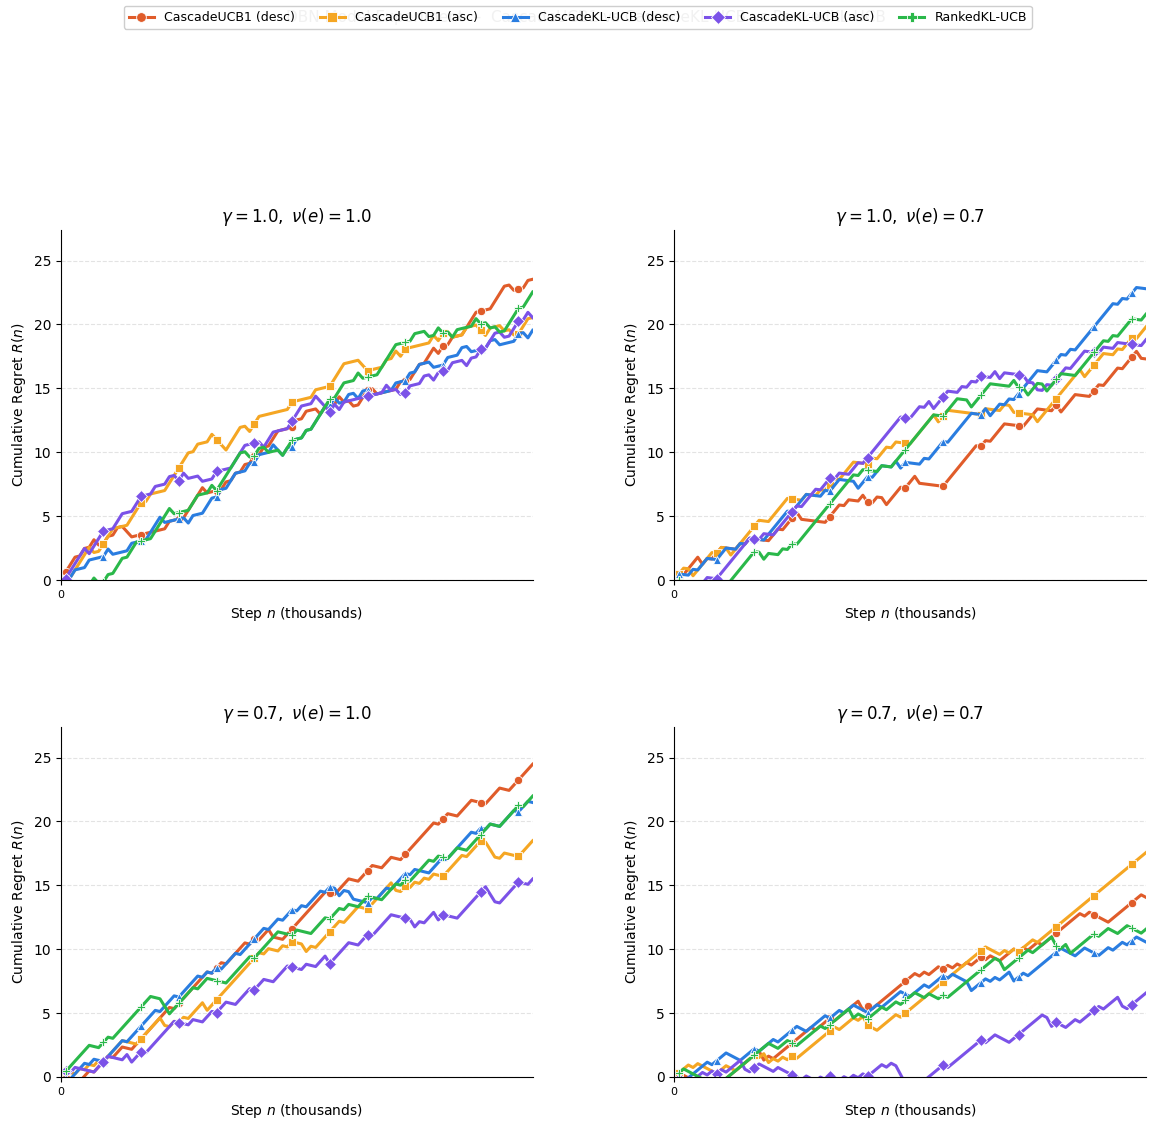

In [16]:
'''Disclaimer: Some portions of this code were generated using AI assistance. All such content has been thoroughly reviewed, verified, and refined to ensure correctness and suitability.'''


''' This code generates the plots mentioned in report'''
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec




def dbn_step(rho: np.ndarray, nu: np.ndarray, gamma: float,
             rec: list, rng: np.random.Generator):
    """
    Parameters  
    rho   : attraction probabilities for each item, shape (L,)
    nu    : satisfaction probabilities for each item, shape (L,)
    gamma : prob of continuing to next item (after non-satisfied examination)
    rec   : ordered list of K item indices
    rng   : numpy random generator

    Returns
    reward    : 1 if user satisfied, 0 otherwise
    last_click: index in rec of last click (-1 if no click)
    n_obs     : number of items examined by the user
    """
    K = len(rec)
    last_click = -1
    reward = 0

    for k, e in enumerate(rec):
        # User examines item e
        if rng.random() < rho[e]:
            # User clicks
            last_click = k
            if rng.random() < nu[e]:
                # Satisfied → stops immediately
                reward = 1
                return reward, last_click, k + 1
            # Not satisfied then continue with prob gamma 
        # Whether attracted-unsatisfied or not attracted, continue with prob gamma
        if k < K - 1:
            if rng.random() >= gamma:
                # User leaves without examining more items
                return reward, last_click, k + 1

    return reward, last_click, K


def dbn_optimal_reward(rho: np.ndarray, nu: np.ndarray,
                       gamma: float, K: int) -> float:
   
    w_bar = rho * nu  # effective satisfaction probability per item

    # Optimal: top-K items by w_bar, ordered decreasingly 
    top_idx = np.argsort(w_bar)[::-1][:K]
    top_w   = w_bar[top_idx]

    reward = 0.0
    not_satisfied_yet = 1.0  
    for k in range(K):
        reward          += (gamma ** k) * top_w[k] * not_satisfied_yet
        not_satisfied_yet *= (1.0 - top_w[k])
    return reward



def _kl_ucb_batch(p_hat: np.ndarray, T: np.ndarray, t: int,
                  c: float = 3.0, n_iter: int = 12, eps: float = 1e-10) -> np.ndarray:
    thresh = np.log(max(t, 1)) + c * np.log(max(np.log(max(t, 1)), 1.0))
    q = np.minimum(p_hat + np.sqrt(thresh / np.maximum(T, 1)), 1.0 - eps)
    q = np.maximum(q, p_hat + eps)
    for _ in range(n_iter):
        p   = np.clip(p_hat, eps, 1.0 - eps)
        qc  = np.clip(q, eps, 1.0 - eps)
        kl  = p * np.log(p / qc) + (1.0 - p) * np.log((1.0 - p) / (1.0 - qc))
        dkl = (1.0 - p) / (1.0 - qc) - p / qc
        f   = T * kl - thresh
        df  = T * dkl
        mask = (T > 0) & (np.abs(df) > eps)
        q[mask] -= f[mask] / df[mask]
        q = np.clip(q, p_hat + eps, 1.0 - eps)
    q[T == 0] = 1.0
    return q


def _ucb1_batch(p_hat: np.ndarray, T: np.ndarray, t: int) -> np.ndarray:
    return np.minimum(p_hat + np.sqrt(1.5 * np.log(max(t-1, 1)) / np.maximum(T, 1)), 1.0)


def _select_top_k(ucbs: np.ndarray, K: int, ascending: bool = False) -> list:
    top_idx = np.argpartition(ucbs, -K)[-K:]
    order   = np.argsort(ucbs[top_idx])
    if not ascending:
        order = order[::-1]
    return top_idx[order].tolist()




class CascadeUCB1_DBN:


    def __init__(self, L: int, K: int, ascending: bool = False):
        self.L = L
        self.K = K
        self.ascending = ascending
        label = "asc" if ascending else "desc"
        self.name = f"CascadeUCB1 ({label})"

    def run(self, rho: np.ndarray, nu: np.ndarray, gamma: float,
            n_steps: int, rng: np.random.Generator) -> np.ndarray:
        L, K = self.L, self.K
        opt  = dbn_optimal_reward(rho, nu, gamma, K)

        T     = np.ones(L, float)
        w_hat = (rng.random(L) < rho * nu).astype(float)

        regret = np.empty(n_steps)
        for s in range(n_steps):
            t   = s + 1
            ucb = _ucb1_batch(w_hat, T, t)
            rec = _select_top_k(ucb, K, self.ascending)

            reward, last_click, n_obs = dbn_step(rho, nu, gamma, rec, rng)
            regret[s] = opt - reward

            # Update: treat last click as the "attractive" signal
            for k in range(n_obs):
                e = rec[k]
                T[e] += 1
                got_reward = float(k == last_click and reward == 1)
                w_hat[e] += (got_reward - w_hat[e]) / T[e]

        return np.cumsum(regret)


class CascadeKL_UCB_DBN:
  

    def __init__(self, L: int, K: int, ascending: bool = False):
        self.L = L
        self.K = K
        self.ascending = ascending
        label = "asc" if ascending else "desc"
        self.name = f"CascadeKL-UCB ({label})"

    def run(self, rho: np.ndarray, nu: np.ndarray, gamma: float,
            n_steps: int, rng: np.random.Generator) -> np.ndarray:
        L, K = self.L, self.K
        opt  = dbn_optimal_reward(rho, nu, gamma, K)

        T     = np.ones(L, float)
        w_hat = (rng.random(L) < rho * nu).astype(float)

        regret = np.empty(n_steps)
        for s in range(n_steps):
            t   = s  + 1
            ucb = _kl_ucb_batch(w_hat, T, t)
            rec = _select_top_k(ucb, K, self.ascending)

            reward, last_click, n_obs = dbn_step(rho, nu, gamma, rec, rng)
            regret[s] = opt - reward

            for k in range(n_obs):
                e = rec[k]
                T[e] += 1
                got_reward = float(k == last_click and reward == 1)
                w_hat[e] += (got_reward - w_hat[e]) / T[e]

        return np.cumsum(regret)


class RankedKL_UCB_DBN:
  

    def __init__(self, L: int, K: int):
        self.L = L
        self.K = K
        self.name = "RankedKL-UCB"

    def run(self, rho: np.ndarray, nu: np.ndarray, gamma: float,
            n_steps: int, rng: np.random.Generator) -> np.ndarray:
        L, K = self.L, self.K
        opt  = dbn_optimal_reward(rho, nu, gamma, K)

        T     = np.ones((K, L), float)
        w_hat = np.zeros((K, L))
        w_hat[0] = (rng.random(L) < rho * nu).astype(float)

        regret = np.empty(n_steps)
        for s in range(n_steps):
            t   = s  + 1
            rec = []
            for pos in range(K):
                ucb = _kl_ucb_batch(w_hat[pos], T[pos], t)
                for e in rec:
                    ucb[e] = -1.0
                rec.append(int(np.argmax(ucb)))

            reward, last_click, n_obs = dbn_step(rho, nu, gamma, rec, rng)
            regret[s] = opt - reward

            for k in range(n_obs):
                e = rec[k]
                T[k, e] += 1
                got_reward = float(k == last_click and reward == 1)
                w_hat[k, e] += (got_reward - w_hat[k, e]) / T[k, e]

        return np.cumsum(regret)




def make_blb_rho(L: int, K: int, p: float, delta: float) -> np.ndarray:
    
    rho = np.full(L, p - delta)
    rho[:K] = p
    return rho


def run_dbn_experiment(
    L: int = 16,
    K: int = 4,
    p: float = 0.2,
    delta: float = 0.15,
    dbn_configs: list = None,   # list of (gamma, nu_val) tuples
    n_steps: int = 100_000,
    n_runs: int = 20,
    seed: int = 42,
    verbose: bool = True,
) -> dict:
    """
   

    Parameters
 
    L, K, p, delta : BLB problem parameters
    dbn_configs    : list of (gamma, nu) pairs to test
    n_steps        : number of learning steps (paper uses 10^5)
    n_runs         : number of independent runs (paper uses 20)
    seed           : master random seed

    Returns
    results : dict keyed by (gamma, nu) ->
                  dict keyed by algorithm name -> mean cumulative regret (n_steps,)
    """
    if dbn_configs is None:
     
        dbn_configs = [
            (1.0, 1.0),
            (1.0, 0.7),
            (0.7, 1.0),
            (0.7, 0.7),
        ]

    rho = make_blb_rho(L, K, p, delta)
    master_rng = np.random.default_rng(seed)
    results = {}

    for gamma, nu_val in dbn_configs:
        nu = np.full(L, nu_val)
        key = (gamma, nu_val)
        label = f"γ={gamma}, ν={nu_val}"

        if verbose:
            print(f"\n{'='*60}")
            print(f"DBN config: {label}  |  L={L}, K={K}, p={p}, Δ={delta}")
            print(f"{'='*60}")

      
        algo_results = {
            "CascadeUCB1 (desc)":   np.zeros(n_steps),
            "CascadeUCB1 (asc)":    np.zeros(n_steps),
            "CascadeKL-UCB (desc)": np.zeros(n_steps),
            "CascadeKL-UCB (asc)":  np.zeros(n_steps),
            "RankedKL-UCB":         np.zeros(n_steps),
        }

        for run_i in range(n_runs):
            s = int(master_rng.integers(1 << 30))
            algos = [
                ("CascadeUCB1 (desc)",   CascadeUCB1_DBN(L, K, False)),
                ("CascadeUCB1 (asc)",    CascadeUCB1_DBN(L, K, True)),
                ("CascadeKL-UCB (desc)", CascadeKL_UCB_DBN(L, K, False)),
                ("CascadeKL-UCB (asc)",  CascadeKL_UCB_DBN(L, K, True)),
                ("RankedKL-UCB",         RankedKL_UCB_DBN(L, K)),
            ]
            for i, (name, alg) in enumerate(algos):
                r = alg.run(rho, nu, gamma, n_steps, np.random.default_rng(s + i))
                algo_results[name] += r

            if verbose and (run_i + 1) % 5 == 0:
                print(f"  Completed {run_i+1}/{n_runs} runs …")

        for name in algo_results:
            algo_results[name] /= n_runs

        if verbose:
            print(f"\n  Final n-step regret ({n_steps:,} steps, avg over {n_runs} runs):")
            for name, curve in algo_results.items():
                print(f"    {name:<28s}: {curve[-1]:.1f}")

        results[key] = algo_results

    return results



PALETTE = {
    #  name                    color   marker  label
    "CascadeUCB1 (desc)":   ("#e05c2a", "o",  "CascadeUCB1 (desc)"),
    "CascadeUCB1 (asc)":    ("#f5a623", "s",  "CascadeUCB1 (asc)"),
    "CascadeKL-UCB (desc)": ("#2a7de0", "^",  "CascadeKL-UCB (desc)"),
    "CascadeKL-UCB (asc)":  ("#7b52e8", "D",  "CascadeKL-UCB (asc)"),
    "RankedKL-UCB":         ("#2ab84a", "P",  "RankedKL-UCB"),
}

N_MARK = 8   # out of 100 x-points after downsampling   8 markers per line


def plot_dbn_results(results: dict, n_steps: int = 100_000,
                     save_path: str = "dbn_experiment.png"):
   
    configs = list(results.keys())
    n_cfg   = len(configs)

    # Downsample to 200 points so markers don't crowd the lines
    ds      = max(1, n_steps // 200)
    steps_k = np.arange(1, n_steps + 1, ds) / 1000   # x-axis in thousands


    ncols = 2
    nrows = (n_cfg + 1) // ncols
    fig   = plt.figure(figsize=(14, 5.5 * nrows))
    gs    = gridspec.GridSpec(nrows, ncols, hspace=0.42, wspace=0.30)
    axes  = [fig.add_subplot(gs[i // ncols, i % ncols]) for i in range(n_cfg)]

  
    all_finals = [
        v[-1]
        for algo_res in results.values()
        for v in algo_res.values()
    ]
    y_max = max(all_finals) * 1.12

    for ax, (gamma, nu_val) in zip(axes, configs):
        algo_res = results[(gamma, nu_val)]

        for name, curve in algo_res.items():
            color, marker, label = PALETTE[name]
            y = curve[::ds]                     # downsample

            # Solid line
            ax.plot(steps_k, y,
                    color=color, linestyle="-", linewidth=2.2,
                    label=label)
            # Markers placed every N_MARK downsampled points
            ax.plot(steps_k[::N_MARK], y[::N_MARK],
                    color=color, marker=marker,
                    linestyle="none", markersize=6,
                    markeredgecolor="white", markeredgewidth=0.6)

        ax.set_xlim(0, n_steps / 1000)
        ax.set_ylim(0, y_max)
        ax.set_xlabel("Step $n$ (thousands)", fontsize=10)
        ax.set_ylabel("Cumulative Regret $R(n)$", fontsize=10)
        ax.set_title(f"$\\gamma={gamma},\\ \\nu(e)={nu_val}$",
                     fontsize=12, fontweight="bold")
        ax.grid(True, linestyle="--", alpha=0.35, linewidth=0.8)
        ax.spines[["top", "right"]].set_visible(False)

        x_ticks = np.arange(0, n_steps / 1000 + 1, 20)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(
            [f"{int(x)}k" if x > 0 else "0" for x in x_ticks], fontsize=8)

    # Build custom handles that show both line and marker
    from matplotlib.lines import Line2D
    handles = []
    for name, (color, marker, label) in PALETTE.items():
        h = Line2D([0], [0], color=color, linewidth=2.2, linestyle="-",
                   marker=marker, markersize=7,
                   markeredgecolor="white", markeredgewidth=0.6,
                   label=label)
        handles.append(h)

    fig.legend(handles=handles, loc="upper center", ncol=5,
               fontsize=9,
               framealpha=0.95, edgecolor="#cccccc")

    fig.suptitle(
        "DBN Model Experiment  –  CascadeUCB1 vs CascadeKL-UCB vs RankedKL-UCB\n",
        fontsize=11, y=1.08
    )

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"\nPlot saved to: {save_path}")
    plt.show()



if __name__ == "__main__":
  
    N_STEPS = 100
    N_RUNS  = 2   
    SEED    = 42

   
    L, K, p, delta = 16, 4, 0.2, 0.15

    DBN_CONFIGS = [
        (1.0, 1.0),   
        (1.0, 0.7),   
        (0.7, 1.0),   
        (0.7, 0.7),  
    ]

    print("Cascading Bandits – DBN Model Experiment ")
    print(f"L={L}, K={K}, p={p}, Δ={delta}, n={N_STEPS:,}, runs={N_RUNS}")

    results = run_dbn_experiment(
        L=L, K=K, p=p, delta=delta,
        dbn_configs=DBN_CONFIGS,
        n_steps=N_STEPS,
        n_runs=N_RUNS,
        seed=SEED,
        verbose=True,
    )

    plot_dbn_results(results, n_steps=N_STEPS, save_path="dbn_experiment_latest_latest.png")